# LeetCode #22: Generate Parentheses

https://leetcode.com/problems/generate-parentheses/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(2^{2n} \cdot n)$ | $O(2^{2n} \cdot n)$ |
| **Backtracking (DFS)** | $O\!\left(\dfrac{4^n}{\sqrt{n}}\right)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force
Generate all $2^{2n}$ sequences of `(` and `)`, then filter for valid ones by checking each with a balance counter. Most sequences are invalid, so the vast majority of work is wasted.

### Optimal: Backtracking (DFS) ★
Build the string character-by-character, tracking open and close counts. Add `(` only when open < n, and add `)` only when close < open. This prunes every invalid branch at the point of construction — only the $C_n$ valid strings (the $n$-th Catalan number) are ever fully built.

**Why this is better than Brute Force:** Brute Force constructs and then validates $2^{2n}$ strings; DFS never builds an invalid prefix, so only $O(C_n)$ strings reach a leaf — roughly $\frac{4^n}{n^{3/2}\sqrt{\pi}}$ instead of $4^n$.

**Constraints:**
* 1 <= n <= 8

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<string> GenerateParenthesis(int n) {
        var result = new List<string>();
        Backtrack(result, new char[2 * n], 0, 0, 0, n);
        return result;
    }

    private void Backtrack(IList<string> result, char[] arr, int pos, int open, int close, int n) {
        if (pos == arr.Length) { result.Add(new string(arr)); return; }
        // Add open paren whenever we still have budget
        if (open < n) {
            arr[pos] = '(';
            Backtrack(result, arr, pos + 1, open + 1, close, n);
        }
        // Add close paren only when it won't exceed open count
        if (close < open) {
            arr[pos] = ')';
            Backtrack(result, arr, pos + 1, open, close + 1, n);
        }
    }
}

### Python

In [ ]:
class Solution:
    def generateParenthesis(self, n: int) -> list[str]:
        result = []
        arr = [''] * (2 * n)

        def backtrack(pos: int, open_count: int, close_count: int) -> None:
            if pos == 2 * n:
                result.append(''.join(arr))
                return
            # Add open paren whenever we still have budget
            if open_count < n:
                arr[pos] = '('
                backtrack(pos + 1, open_count + 1, close_count)
            # Add close paren only when it won't exceed open count
            if close_count < open_count:
                arr[pos] = ')'
                backtrack(pos + 1, open_count, close_count + 1)

        backtrack(0, 0, 0)
        return result

### Go

In [ ]:
func generateParenthesis(n int) []string {
    result := []string{}
    arr := make([]byte, 2*n)
    var backtrack func(pos, open, close int)
    backtrack = func(pos, open, close int) {
        if pos == 2*n {
            result = append(result, string(arr))
            return
        }
        // Add open paren whenever we still have budget
        if open < n {
            arr[pos] = '('
            backtrack(pos+1, open+1, close)
        }
        // Add close paren only when it won't exceed open count
        if close < open {
            arr[pos] = ')'
            backtrack(pos+1, open, close+1)
        }
    }
    backtrack(0, 0, 0)
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn generate_parenthesis(n: i32) -> Vec<String> {
        let mut result = Vec::new();
        let mut arr = vec![b' '; (2 * n) as usize];
        Self::backtrack(&mut result, &mut arr, 0, 0, 0, n);
        result
    }

    fn backtrack(result: &mut Vec<String>, arr: &mut Vec<u8>, pos: usize, open: i32, close: i32, n: i32) {
        if pos == arr.len() {
            result.push(String::from_utf8(arr.clone()).unwrap());
            return;
        }
        // Add open paren whenever we still have budget
        if open < n {
            arr[pos] = b'(';
            Self::backtrack(result, arr, pos + 1, open + 1, close, n);
        }
        // Add close paren only when it won't exceed open count
        if close < open {
            arr[pos] = b')';
            Self::backtrack(result, arr, pos + 1, open, close + 1, n);
        }
    }
}

## Example Scenarios

**1. Common Case**
**Input:** n = 3
The DFS tree has open/close counters gating every branch. The 5 valid strings (the 3rd Catalan number $C_3 = 5$) are produced: "((()))", "(()())", "(())()", "()(())", "()()()". No invalid prefix is ever extended — the two guards (`open < n`, `close < open`) prune the tree at construction time.

**2. Slightly Complex**
**Input:** n = 2
DFS explores: pos=0 adds `(` (open=1) → pos=1 can add `(` (open=2) or `)` (close=1). From open=2/close=0: only `)` is legal → yields "(())" and "()()". Exactly $C_2 = 2$ results. The branching factor is at most 2 at each node but usually 1.

**3. Edge Case: Time Factor**
**Input:** n = 8 (maximum constraint)
$C_8 = 1430$ valid strings, each of length 16. The DFS tree has at most $2 \times 8 = 16$ levels. Every leaf produces a valid string — zero validation passes needed. Total work is proportional to $1430 \times 16 \approx 22{,}880$ character writes, vs Brute Force's $2^{16} = 65{,}536$ candidate sequences each requiring an $O(16)$ validation scan ($\approx 1{,}048{,}576$ total operations).

**4. Edge Case: Space Factor**
**Input:** n = 8
The call stack is at most $2n = 16$ frames deep (one per character position). Each frame stores only `pos`, `open`, `close` — three integers. Auxiliary stack space is $O(n)$ regardless of how many valid strings exist. The output list itself is unavoidable at $O(C_n \cdot n)$.

**5. Almost-Impossible but Plausible**
**Input:** n = 1
Only one valid string: "()". At pos=0, only `(` is legal (open=0 < 1). At pos=1, only `)` is legal (close=0 < open=1). At pos=2, pos == 2n → capture "()". The DFS makes exactly 3 calls (root + 2 children). $C_1 = 1$, so the single-leaf tree is the smallest non-trivial case.

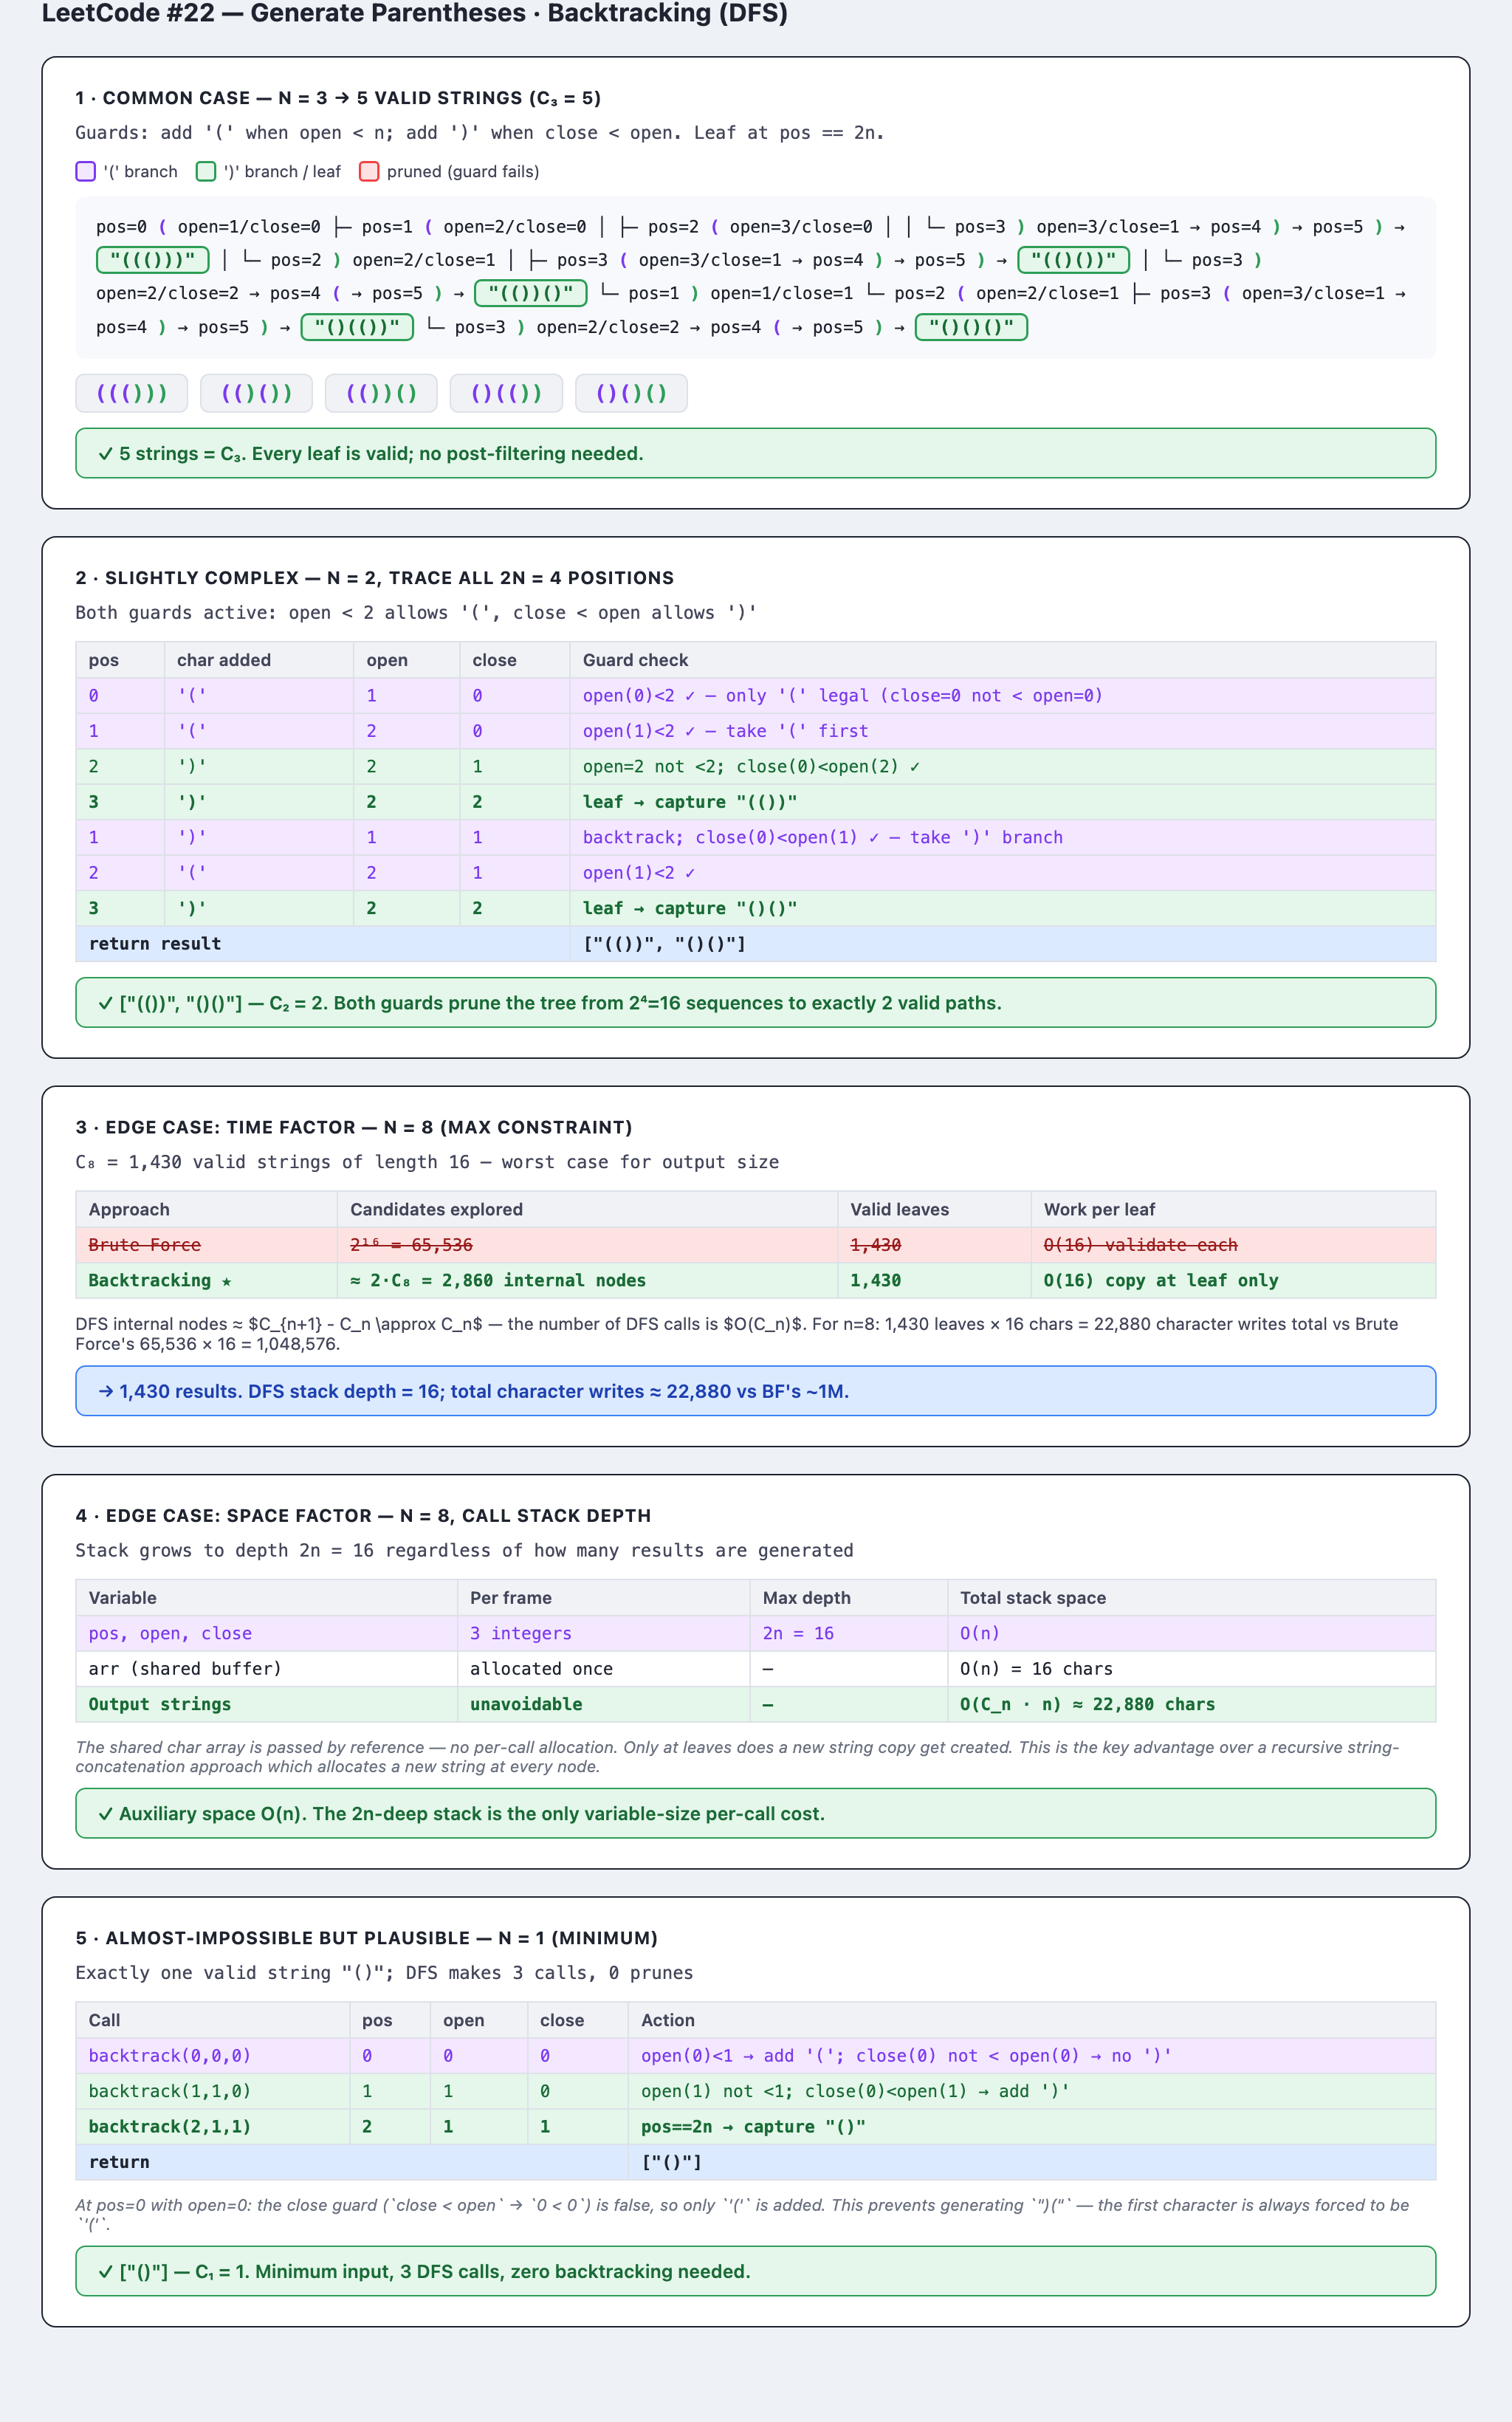